In [3]:
import os
from dotenv import load_dotenv
import google.generativeai as genai
from rich.console import Console
from rich.markdown import Markdown

# Initialize the pretty console
console = Console()


load_dotenv(dotenv_path="../.env")

api_key = os.getenv("GOOGLE_API_KEY")
if not api_key:
    console.print("[bold red]❌ ERROR: GOOGLE_API_KEY not found. Check your .env file.[/bold red]")
else:
    genai.configure(api_key=api_key)
    
    
   
    model_flash = genai.GenerativeModel('gemini-2.5-flash')
    model_pro = genai.GenerativeModel('gemini-2.5-pro')
    
    console.print("[bold green]✅ Cell 1 Complete: System Online and Gemini API Connected![/bold green]")

c:\Users\ASUS\Desktop\AI-FOR-BHARAT-MVP\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\ASUS\AppData\Local\Temp\ipykernel_14348\2276232108.py:3: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


✅ Cell 1 Complete: System Online and Gemini API Connected!

In [4]:
import PIL.Image

# Point this to the photo you took of your screen
image_path = "../data/bidders/Bidder_C_GammaInfra/Scanned_Work_Proof.jpeg" # Change .jpeg to .jpg or .png if needed

try:
    # Load the image
    scanned_img = PIL.Image.open(image_path)
    console.print(f"[blue]✅ Successfully loaded Image: {image_path}[/blue]")
    
    # The Prompt for the AI
    vision_prompt = """
    You are an expert Government Document Auditor. Read this scanned image carefully.
    
    Provide a brief summary with:
    1. The exact name of the company.
    2. The exact number of years of experience they have.
    3. The full text extracted from the document.
    """
    
    console.print("🧠 [italic]Sending image to Gemini Vision...[/italic]")
    
    
    response = model_flash.generate_content([vision_prompt, scanned_img])
    
    console.print("\n[bold]--- 📄 AI VISION RESULT ---[/bold]")
    console.print(Markdown(response.text))

except FileNotFoundError:
    console.print(f"[bold red]❌ ERROR: File not found at {image_path}. Check your folder and spelling![/bold red]")
except Exception as e:
    console.print(f"[bold red]❌ Unexpected Error: {e}[/bold red]")

✅ Successfully loaded Image: ../data/bidders/Bidder_C_GammaInfra/Scanned_Work_Proof.jpeg

🧠 Sending image to Gemini Vision...

--- 📄 AI VISION RESULT ---

Here is the summary based on the document provided:                                                                

Summary:                                                                                                           

 1 The exact name of the company: M/s Gamma Infra Projects                                                         
 2 The exact number of years of experience they have: 4 (four) years                                               
 3 The full text extracted from the document: File: Scanned_Work_Proof.jpg Put this in full screen, zoom in a bit, 
   and take a photo of your monitor with your phone.                                                               
   TO WHOM IT MAY CONCERN SUBJECT: PROJECT COMPLETION AND EXPERIENCE CERTIFICATE                                   
   This is to certify that M/s Gamma Infra Projects, headquartered in Pune, Maharashtra, was awarded the contract  
   for the "Modernization of State Highway 14" under Contract Ref No. PWD/SH14/2021-09.                            
   The agency mobilized resources efficiently and demonstrated excellent project management skills. We confirm that
   Gamma Infra has been actively undertaking and completing heavy civil construction projects for our department   
   for the past 4 (four) years. Their work quality has been satisfactory and within safety parameters.             
   Issued By: Chief Engineer, Public Works Department

In [5]:
import json
from pypdf import PdfReader
from pydantic import BaseModel, Field
from typing import List

# --- 1. DEFINE THE CONTRACT (IN THE NOTEBOOK) ---
class TenderCriterion(BaseModel):
    id: str = Field(description="Unique identifier like CRIT_001")
    category: str = Field(description="Technical, Financial, or Compliance")
    description: str = Field(description="The actual rule text (e.g., Minimum turnover of 5 Crore)")
    is_mandatory: bool = Field(description="True if this is a 'must-have' requirement")
    threshold: str = Field(description="Specific numerical value or exact keyword to match against")

class TenderRequirementList(BaseModel):
    requirements: List[TenderCriterion]

# --- 2. READ THE TENDER PDF ---
tender_path = "../data/tenders/CRPF_Rulebook.pdf"

try:
    reader = PdfReader(tender_path)
    tender_text = ""
    for page in reader.pages:
        text = page.extract_text()
        if text:
            tender_text += text + "\n"
            
    console.print(f"[blue]✅ Successfully read {len(tender_text)} characters from the Tender PDF[/blue]")
    
    # --- 3. THE PROMPT ---
    extraction_prompt = f"""
    You are a meticulous Government Procurement Officer.
    Read the following Notice Inviting Tender (NIT) document carefully.
    
    Extract all the mandatory eligibility criteria. Pay special attention to numerical thresholds (like 5 Crore) and statutory requirements (like GST or Experience).
    
    TENDER TEXT:
    {tender_text}
    """
    
    console.print("🧠 [italic]Extracting strict Rules using Gemini Pro...[/italic]")
    

    response = model_pro.generate_content(
        extraction_prompt,
        generation_config=genai.GenerationConfig(
            response_mime_type="application/json",
            response_schema=TenderRequirementList
        )
    )
    
    # --- 5. DISPLAY THE RESULT ---
    console.print("\n[bold]--- 📋 EXTRACTED TENDER RULES (STRUCTURED JSON) ---[/bold]")
    tender_rules = json.loads(response.text)
    
    # Use rich to print the JSON beautifully in the terminal
    console.print_json(data=tender_rules)

except FileNotFoundError:
    console.print(f"[bold red]❌ ERROR: Could not find Tender at {tender_path}. Check your spelling![/bold red]")
except Exception as e:
    console.print(f"[bold red]❌ Unexpected Error: {e}[/bold red]")

✅ Successfully read 2177 characters from the Tender PDF

🧠 Extracting strict Rules using Gemini Pro...

--- 📋 EXTRACTED TENDER RULES (STRUCTURED JSON) ---

{
  "requirements": [
    {
      "category": "Financial",
      "description": "Bidder must have achieved a Minimum Annual Financial Turnover of ₹5,00,00,000 (Five Crore Rupees) in the immediate preceding financial year (2024-2025).",
      "id": "CRIT_001",
      "is_mandatory": true,
      "threshold": "50000000"
    },
    {
      "category": "Compliance",
      "description": "The bidder must possess a valid and active GST Registration Certificate.",
      "id": "CRIT_002",
      "is_mandatory": true,
      "threshold": "Valid GST Registration"
    },
    {
      "category": "Technical",
      "description": "Bidder must have a minimum of 3 (three) years of operational experience in providing similar structural or construction services to state/central government bodies or large public sector undertakings.",
      "id": "CRIT_003",
      "is_mandatory": true,
      "threshold": "3 years"
    }
  ]
}

In [6]:
import os
from langchain_community.document_loaders import PyPDFLoader 
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_chroma import Chroma

console.print("[bold cyan]Building the Vector Memory (ChromaDB)...[/bold cyan]")

embeddings = GoogleGenerativeAIEmbeddings(model="models/embedding-001")
bidder_a_folder = "../data/bidders/Bidder_A_AlphaCorp/"

documents = []
import os
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_chroma import Chroma

console.print("[bold cyan]Building the Vector Memory (ChromaDB)...[/bold cyan]")


embeddings = GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001")


bidder_a_folder = "../data/bidders/Bidder_A_AlphaCorp/"
documents = []

try:
    # Loop through the folder and load every PDF
    for filename in os.listdir(bidder_a_folder):
        if filename.endswith(".pdf"):
            file_path = os.path.join(bidder_a_folder, filename)
            loader = PyPDFLoader(file_path)
            documents.extend(loader.load())
            console.print(f"📄 Loaded PDF: [green]{filename}[/green]")

    
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=500,  
        chunk_overlap=50 
    )
    chunks = text_splitter.split_documents(documents)
    console.print(f"✂️ Sliced documents into [bold yellow]{len(chunks)}[/bold yellow] searchable chunks.")

    
    vector_store = Chroma.from_documents(
        documents=chunks,
        embedding=embeddings,
        collection_name="bidder_a_memory"
    )
    console.print("[bold green]✅ Vector Store Built Successfully![/bold green]")

    
    test_rule = "What is the total annual financial turnover of the company?"
    console.print(f"\n[italic]🔎 Running Test Search for: '{test_rule}'...[/italic]")
    
    results = vector_store.similarity_search(test_rule, k=2)
    
    console.print("\n[bold]--- 🎯 SEARCH RESULTS ---[/bold]")
    for i, res in enumerate(results):
        
        source = res.metadata.get('source', 'Unknown').split('/')[-1].split('\\')[-1]
        console.print(f"\n[yellow]Result {i+1} (Found in {source}):[/yellow]")
        console.print(res.page_content)
        
except FileNotFoundError:
    console.print(f"[bold red]❌ ERROR: Folder not found at {bidder_a_folder}[/bold red]")
except Exception as e:
    console.print(f"[bold red]❌ Unexpected Error: {e}[/bold red]")



Building the Vector Memory (ChromaDB)...

Building the Vector Memory (ChromaDB)...

📄 Loaded PDF: Annual_Turnover.pdf

📄 Loaded PDF: GST_Certificate.pdf

✂️ Sliced documents into 4 searchable chunks.

...

--- 🎯 SEARCH RESULTS ---

Result 1 (Found in Annual_Turnover.pdf):

INDEPENDENT AUDITOR'S REPORT ON FINANCIAL TURNOVER 
To The Board of Directors, AlphaCorp Construction Solutions We have audited the 
financial statements of AlphaCorp Construction Solutions Pvt. Ltd., which comprise the 
balance sheet as of March 31, 2025, and the profit and loss account for the year then 
ended. 
Based on our audit procedures and the information and explanations provided to us by 
the management, we hereby certify that the gross annual turnover derived from core

Result 2 (Found in Annual_Turnover.pdf):

business operations for the financial year 2024-2025 is ₹12,50,00,000 (Twelve Crore 
Fifty Lakh Rupees). 
This certificate is issued specifically for the purpose of participating in government 
tenders and should not be used for banking loan facilitations. 
Firm Registration Number: 102938W Chartered Accountant: Rajesh Sharma (M.No: 
049382) Date: 10th April 2025

In [7]:
from pydantic import BaseModel, Field
from typing import Optional, Literal
import json

# --- 1. DEFINE THE VERDICT CONTRACT ---
class BidderEvidence(BaseModel):
    status: Literal["Found", "Missing", "Ambiguous"]
    found_value: Optional[str] = Field(description="The exact value found in the document (e.g., 12.5 Crore)")
    source_document: str = Field(description="Name of the file where evidence was found")
    snippet: str = Field(description="A short 1-sentence quote from the document proving the value")

class CriterionVerdict(BaseModel):
    criterion_id: str
    is_eligible: bool
    reasoning: str = Field(description="Step-by-step explanation of why they passed or failed")
    evidence: Optional[BidderEvidence]

# --- 2. THE JUDGE FUNCTION ---
def evaluate_rule(criterion, v_store):
    console.print(f"\n[bold cyan]⚖️ Evaluating Rule: {criterion['id']}[/bold cyan]")
    console.print(f"[italic]Rule: {criterion['description']}[/italic]")
    
    # Step A: Search the memory for this specific rule
    console.print("🔎 [dim]Searching Bidder's documents for evidence...[/dim]")
    docs = v_store.similarity_search(criterion['description'], k=3)
    
    # Combine the found text into one big context string
    context = ""
    for doc in docs:
        source = doc.metadata.get('source', 'Unknown').split('/')[-1].split('\\')[-1]
        context += f"\n--- From Document: {source} ---\n{doc.page_content}\n"
        
    # Step B: The Prompt for Gemini Pro
    judge_prompt = f"""
    You are an impartial Government Procurement Auditor.
    Evaluate if the bidder meets the following criterion based ONLY on the provided document context.
    
    CRITERION TO EVALUATE:
    ID: {criterion['id']}
    Category: {criterion['category']}
    Description: {criterion['description']}
    Mandatory: {criterion['is_mandatory']}
    Threshold to meet: {criterion['threshold']}
    
    BIDDER DOCUMENT CONTEXT:
    {context}
    
    Instructions:
    1. If the evidence clearly meets or exceeds the threshold, mark is_eligible as true.
    2. If the evidence is below the threshold, or missing entirely, mark is_eligible as false.
    3. Output your final verdict in strict JSON format.
    """
    
    # Step C: Ask Gemini Pro for the Verdict
    console.print("🧠 [dim]Gemini Pro is analyzing the evidence...[/dim]")
    response = model_pro.generate_content(
        judge_prompt,
        generation_config=genai.GenerationConfig(
            response_mime_type="application/json",
            response_schema=CriterionVerdict
        )
    )
    
    return json.loads(response.text)

# --- 3. TEST THE JUDGE ON RULE 1 ---
try:
    
    first_rule = tender_rules['requirements'][0]
    
    # Run the judge!
    verdict = evaluate_rule(first_rule, vector_store)
    
    console.print("\n[bold green]--- 🧑‍⚖️ FINAL VERDICT ---[/bold green]")
    console.print_json(data=verdict)

except Exception as e:
    console.print(f"[bold red]❌ Error: {e}[/bold red]")

⚖️ Evaluating Rule: CRIT_001

Rule: Bidder must have achieved a Minimum Annual Financial Turnover of ₹5,00,00,000 (Five Crore Rupees) in the 
immediate preceding financial year (2024-2025).

🔎 Searching Bidder's documents for evidence...

🧠 Gemini Pro is analyzing the evidence...

--- 🧑‍⚖️ FINAL VERDICT ---

{
  "criterion_id": "CRIT_001",
  "evidence": {
    "found_value": "₹12,50,00,000",
    "snippet": "business operations for the financial year 2024-2025 is ₹12,50,00,000 (Twelve Crore Fifty Lakh Rupees).",
    "source_document": "Annual_Turnover.pdf",
    "status": "Found"
  },
  "is_eligible": true,
  "reasoning": "Step 1: The criterion requires a minimum annual financial turnover of ₹5,00,00,000 for the financial year 2024-2025. Step 2: The document 'Annual_Turnover.pdf' provides evidence of an annual turnover of ₹12,50,00,000 for the specified financial year. Step 3: The bidder's turnover of ₹12,50,00,000 is greater than the required threshold of ₹5,00,00,000. Therefore, the bidder meets this criterion."
}

In [8]:
import operator
from typing import TypedDict, List, Dict, Any, Annotated
from rich.panel import Panel

console.print("[bold cyan]Building LangGraph State & Nodes...[/bold cyan]")


class AuditState(TypedDict):
    rules: List[Dict]                           
    results: Annotated[List[Dict], operator.add] # The verdicts (appended)
    current_index: int                          # Which rule are we currently judging?
    needs_review: bool                          # Flag for Human-in-the-Loop


def evaluate_next_rule_node(state: AuditState):
    """This node grabs the current rule, evaluates it, and updates the state."""
    current_idx = state["current_index"]
    rule = state["rules"][current_idx]
    
    console.print(Panel(f"🤖 LangGraph Node: Processing Rule {current_idx + 1} of {len(state['rules'])}", border_style="magenta"))
    
    # Run our Judge function from Cell 5!
    verdict = evaluate_rule(rule, vector_store)
    
    # If the AI flags them as ineligible, trigger the "Human Review" flag
    flag_review = state.get("needs_review", False)
    if not verdict["is_eligible"]:
        flag_review = True
        console.print("[bold red]⚠️ INELIGIBILITY DETECTED - Flagging for review![/bold red]")
        
    # Return the updates to the State
    return {
        "results": [verdict], # operator.add will append this to the existing list
        "current_index": current_idx + 1,
        "needs_review": flag_review
    }

# --- 3. DEFINE THE ROUTING LOGIC (The Conditional Edge) ---
def should_continue(state: AuditState):
    """This function decides if we loop again or finish the graph."""
    if state["current_index"] < len(state["rules"]):
        return "evaluate_next_rule" # Keep looping
    else:
        return "END" # We finished all rules

console.print("[bold green]✅ LangGraph Architecture Defined![/bold green]")

Building LangGraph State & Nodes...

✅ LangGraph Architecture Defined!

In [9]:
from langgraph.graph import StateGraph, END
from rich.table import Table

console.print("[bold cyan]Wiring up the LangGraph State Machine...[/bold cyan]")

# --- 1. BUILD THE GRAPH ---
workflow = StateGraph(AuditState)

# Add our Worker Node
workflow.add_node("evaluator", evaluate_next_rule_node)

# Set the starting point
workflow.set_entry_point("evaluator")

# Add the Conditional Edge (The Loop)
workflow.add_conditional_edges(
    "evaluator",
    should_continue,
    {
        "evaluate_next_rule": "evaluator", # If we need to continue, go back to the evaluator
        "END": END                         # If we are done, stop the graph
    }
)

# Compile the Graph into an executable application
app = workflow.compile()
console.print("[bold green]✅ Graph Compiled Successfully![/bold green]\n")

# --- 2. RUN THE GRAPH ON BIDDER A ---
console.print("[bold magenta]🚀 INITIATING AUTOPILOT AUDIT FOR BIDDER A...[/bold magenta]")

# Define the initial state (Starting at Rule 0, empty results)
initial_state = {
    "rules": tender_rules["requirements"],
    "results": [],
    "current_index": 0,
    "needs_review": False
}

# Execute the graph
final_state = app.invoke(initial_state)

# --- 3. GENERATE THE MASTER REPORT ---
console.print("\n[bold yellow]=================================================[/bold yellow]")
console.print("[bold yellow]          📄 FINAL AUDIT REPORT: BIDDER A        [/bold yellow]")
console.print("[bold yellow]=================================================[/bold yellow]\n")

# Create a beautiful terminal table
table = Table(show_header=True, header_style="bold magenta")
table.add_column("Rule ID", style="dim", width=12)
table.add_column("Requirement", width=40)
table.add_column("Status", justify="center")
table.add_column("Evidence Found", style="cyan")

# Loop through the final results and populate the table
all_passed = True
for result in final_state["results"]:
    # Check if this rule failed
    if not result["is_eligible"]:
        all_passed = False
        status = "[bold red]FAIL ❌[/bold red]"
    else:
        status = "[bold green]PASS ✅[/bold green]"
        
    evidence_text = result.get("evidence", {}).get("found_value", "No value extracted")
    if result.get("evidence", {}).get("status") == "Missing":
        evidence_text = "[red]Not found in documents[/red]"

    table.add_row(
        result["criterion_id"],
        result.get("reasoning", "")[:60] + "...", # Truncate reasoning for the table
        status,
        evidence_text
    )

console.print(table)

# Final Output Decision
console.print("\n[bold]OVERALL SYSTEM VERDICT:[/bold]")
if final_state["needs_review"]:
    console.print("[bold red]⚠️ BIDDER FAILED MANDATORY CRITERIA. Flagged for Human Review.[/bold red]")
else:
    console.print("[bold green]✅ BIDDER APPROVED. All mandatory criteria met automatically.[/bold green]")

Wiring up the LangGraph State Machine...

✅ Graph Compiled Successfully!

🚀 INITIATING AUTOPILOT AUDIT FOR BIDDER A...

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ 🤖 LangGraph Node: Processing Rule 1 of 3                                                                       │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

⚖️ Evaluating Rule: CRIT_001

...

          📄 FINAL AUDIT REPORT: BIDDER A        

=================================================

┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃ Rule ID      ┃ Requirement                              ┃ Status  ┃ Evidence Found ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━┩
│ CRIT_001     │ Step 1: The criterion requires a minimum │ PASS ✅ │ ₹12,50,00,000  │
│              │ annual financial tu...                   │         │                │
│ CRIT_002     │ The bidder has provided a GST            │ PASS ✅ │ ACTIVE         │
│              │ Registration Certificate which...        │         │                │
│ CRIT_003     │ The bidder must demonstrate at least 3   │ FAIL ❌ │                │
│              │ years of operational ...                 │         │                │
└──────────────┴──────────────────────────────────────────┴─────────┴────────────────┘

OVERALL SYSTEM VERDICT:

⚠️ BIDDER FAILED MANDATORY CRITERIA. Flagged for Human Review.

In [1]:
print("hello")

hello


📸 Generating LangGraph Architecture Diagram...

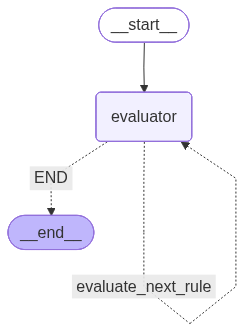

In [10]:
from IPython.display import Image, display

console.print("[bold cyan]📸 Generating LangGraph Architecture Diagram...[/bold cyan]")

try:
    # LangGraph automatically converts your 'app' into a Mermaid PNG
    graph_image = app.get_graph().draw_mermaid_png()
    
    # Display it beautifully in the notebook
    display(Image(graph_image))
    
except Exception as e:
    console.print(f"[bold red]❌ Error generating graph: {e}[/bold red]")
    console.print("[italic dim]Note: You might need to install 'pygraphviz' or run this in an environment with Graphviz installed.[/italic dim]")